In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import RNN_preprocessing_whole as rp 

In [4]:
X_seq_train = rp.X_seq_train
X_seq_test = rp.X_seq_test
y_seq_train = rp.y_seq_train
y_seq_test = rp.y_seq_test

In [5]:
# Clear memory associated with the module
import sys
del rp
if 'RNN_preprocessing_whole' in sys.modules:
    del sys.modules['RNN_preprocessing_whole']

# Clear memory from global variables if needed
import gc
gc.collect()

5

In [6]:
X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(X_seq_train, y_seq_train, test_size=0.2, random_state=0)

In [7]:
X_train = X_seq_train
X_val = X_seq_val
y_train = y_seq_train
y_val = y_seq_val 

In [8]:
# Delete the training/test split variables after they are used
del X_seq_train, X_seq_val, y_seq_train, y_seq_val

# Force garbage collection
gc.collect()

0

LSTM

In [9]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def call(self, inputs):
        """
        Applies attention mechanism to the inputs.

        Args:
            inputs: Tensor of shape (batch_size, seq_length, features).

        Returns:
            Tensor of shape (batch_size, features).
        """
        query = inputs  # Use the same input as query, key, and value
        key = inputs
        value = inputs

        # Compute attention scores
        scores = tf.matmul(query, key, transpose_b=True)  # Shape: (batch, seq_length, seq_length)
        scores = tf.nn.softmax(scores, axis=-1)  # Normalize scores

        # Weighted sum of the values
        context = tf.matmul(scores, value)  # Shape: (batch, seq_length, features)

        return context


In [10]:
def build_bilstm_with_attention(input_shape, num_classes):
    """
    Builds a BiLSTM model with an attention mechanism.

    Args:
        input_shape (tuple): Shape of the input data (seq_length, num_features).
        num_classes (int): Number of output classes.

    Returns:
        keras.Model: Compiled BiLSTM model with attention.
    """
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Attention()(x)  # Add attention mechanism
    x = TimeDistributed(Dense(64, activation="relu"))(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [11]:
seq_length = 10

In [12]:
#Model for the BiPo 214 chain
model = build_bilstm_with_attention((seq_length, X_train.shape[2]), y_train.shape[2])

model.summary()

2025-04-25 14:45:18.478023: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10, 6)]           0         
                                                                 
 bidirectional (Bidirection  (None, 10, 128)           36352     
 al)                                                             
                                                                 
 attention (Attention)       (None, 10, 128)           0         
                                                                 
 time_distributed (TimeDist  (None, 10, 64)            8256      
 ributed)                                                        
                                                                 
 dense_1 (Dense)             (None, 10, 10)            650       
                                                                 
Total params: 45258 (176.79 KB)
Trainable params: 45258 (176.

In [13]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [14]:
# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


6184

In [15]:
# Train model 1
history = model.fit(X_train, y_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X_val, y_val),
                      callbacks=callbacks)

Epoch 1/200
16108/16108 - 892s - loss: 0.4074 - accuracy: 0.8342 - val_loss: 0.2747 - val_accuracy: 0.8910 - lr: 0.0010 - 892s/epoch - 55ms/step
Epoch 2/200
16108/16108 - 664s - loss: 0.2708 - accuracy: 0.8925 - val_loss: 0.2625 - val_accuracy: 0.8964 - lr: 0.0010 - 664s/epoch - 41ms/step
Epoch 3/200
16108/16108 - 675s - loss: 0.2623 - accuracy: 0.8956 - val_loss: 0.2541 - val_accuracy: 0.8995 - lr: 0.0010 - 675s/epoch - 42ms/step
Epoch 4/200
16108/16108 - 826s - loss: 0.2571 - accuracy: 0.8973 - val_loss: 0.2469 - val_accuracy: 0.9017 - lr: 0.0010 - 826s/epoch - 51ms/step
Epoch 5/200
16108/16108 - 609s - loss: 0.2542 - accuracy: 0.8982 - val_loss: 0.2474 - val_accuracy: 0.9013 - lr: 0.0010 - 609s/epoch - 38ms/step
Epoch 6/200
16108/16108 - 610s - loss: 0.2521 - accuracy: 0.8990 - val_loss: 0.2916 - val_accuracy: 0.8802 - lr: 0.0010 - 610s/epoch - 38ms/step
Epoch 7/200
16108/16108 - 610s - loss: 0.2502 - accuracy: 0.8996 - val_loss: 0.2532 - val_accuracy: 0.8980 - lr: 0.0010 - 610s/epo

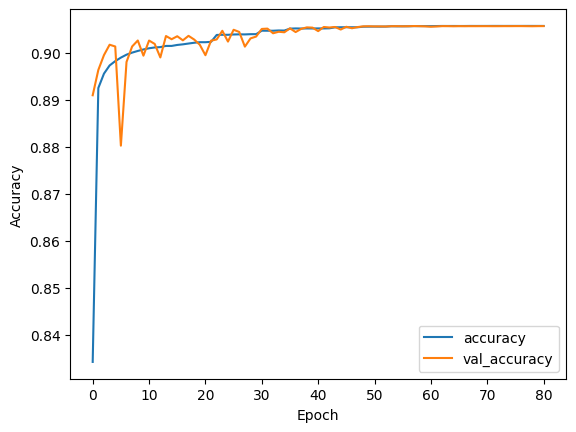

In [16]:
#plotting the accuracy of the first model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

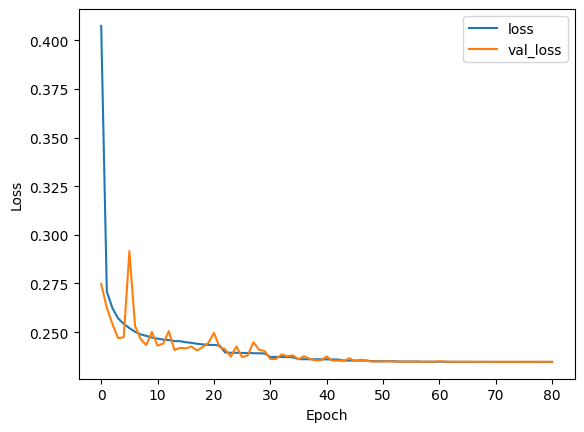

In [17]:
#plotting the loss over epoch for the first model
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
#save the first trained model
model.save('../models/model_bidirec_lstm_whole.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 